# 03 – Fullstendig regresjonsprosjekt: pipeline, modellsammenligning og tolkning
*Data Mining & Analytics – Samling 2, dag 2*

Vi predikerer drivstofforbruk (`mpg`) med både numeriske og kategoriske variabler, sammenligner flere modeller, og forklarer den valgte.

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.5)
rng = np.random.default_rng(42)

In [2]:
from sklearn.model_selection import train_test_split, RepeatedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

df = pd.read_csv("../Data/mpg.csv")
df = df.drop(columns="name")
y = df.pop("mpg")
X_train, X_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, "| manglende verdier i trening:\n", X_train.isna().sum()[X_train.isna().sum() > 0])

(318, 7) (80, 7) | manglende verdier i trening:
 horsepower    5
dtype: int64


## Preprosessering i en pipeline

Numeriske: imputer (median) → skaler. Kategoriske: one-hot. Alt lærer *kun* fra treningsdata.

In [3]:
num = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
kat = ["origin"]
prep = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), num),
    ("kat", OneHotEncoder(handle_unknown="ignore"), kat),
])
modeller = {
    "Baseline": DummyRegressor(),
    "Lineær": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "kNN": KNeighborsRegressor(n_neighbors=7),
    "Random forest": RandomForestRegressor(n_estimators=200, random_state=0),
    "Gradient boosting": GradientBoostingRegressor(random_state=0),
}
pipes = {navn: Pipeline([("prep", prep), ("modell", m)]) for navn, m in modeller.items()}

## Sammenligning med repetert kryssvalidering (5-fold × 5)

                   RMSE snitt  RMSE SD
Gradient boosting        2.92     0.36
Random forest            2.95     0.39
kNN                      3.14     0.37
Lineær                   3.46     0.32
Ridge                    3.46     0.32
Baseline                 7.93     0.56


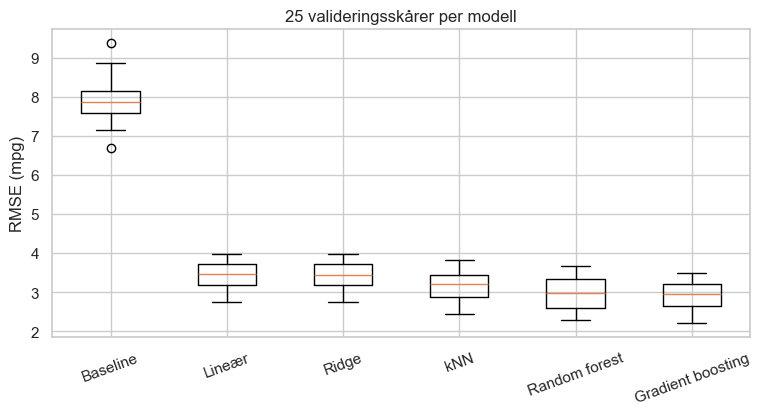

In [4]:
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=1)
skarer = {navn: -cross_val_score(p, X_train, y_train, cv=cv, scoring="neg_root_mean_squared_error") for navn, p in pipes.items()}
tab = pd.DataFrame({n: [s.mean(), s.std()] for n, s in skarer.items()}, index=["RMSE snitt", "RMSE SD"]).T.round(2)
print(tab.sort_values("RMSE snitt"))

plt.figure(figsize=(9, 4))
plt.boxplot(list(skarer.values()), tick_labels=list(skarer.keys())); plt.ylabel("RMSE (mpg)"); plt.xticks(rotation=20)
plt.title("25 valideringsskårer per modell"); plt.show()

Er den beste modellen signifikant bedre enn nest beste? Bruker her korrigert paret t-test (Nadeau–Bengio) på differansene fra de samme foldene:

In [5]:
def korrigert_ttest(a, b, n_test_over_train):
    d = np.asarray(a) - np.asarray(b)
    J = len(d)
    t = d.mean() / np.sqrt((1 / J + n_test_over_train) * d.var(ddof=1))
    return t, 2 * stats.t.sf(abs(t), J - 1), d.mean()

rangert = tab.sort_values("RMSE snitt").index.tolist()
beste, nest = rangert[0], rangert[1]
t, p, dmean = korrigert_ttest(skarer[beste], skarer[nest], 1 / 4)
print(f"{beste} vs {nest}: differanse i RMSE = {dmean:.3f}, korrigert t = {t:.2f}, p = {p:.3f}")

Gradient boosting vs Random forest: differanse i RMSE = -0.028, korrigert t = -0.28, p = 0.785


## Hyperparametersøk for den valgte modellen

In [ ]:
model_pipeline = Pipeline([("prep", prep), ("modell", GradientBoostingRegressor(random_state=0))])
grid = {"modell__n_estimators": [100, 300], "modell__learning_rate": [0.03, 0.1], "modell__max_depth": [2, 3]}

gs = GridSearchCV(model_pipeline, grid, cv=5, scoring="neg_root_mean_squared_error").fit(X_train, y_train)

print("Beste:", gs.best_params_, "  CV-RMSE:", (-gs.best_score_).round(2))

Beste: {'modell__learning_rate': 0.1, 'modell__max_depth': 2, 'modell__n_estimators': 100}   CV-RMSE: 2.95


## Endelig test og feilanalyse

Test:  RMSE = 2.39 mpg,  MAE = 1.83 mpg,  R2 = 0.894
Gjennomsnittlig absolutt feil i forhold til gjennomsnittlig mpg: 7.9%


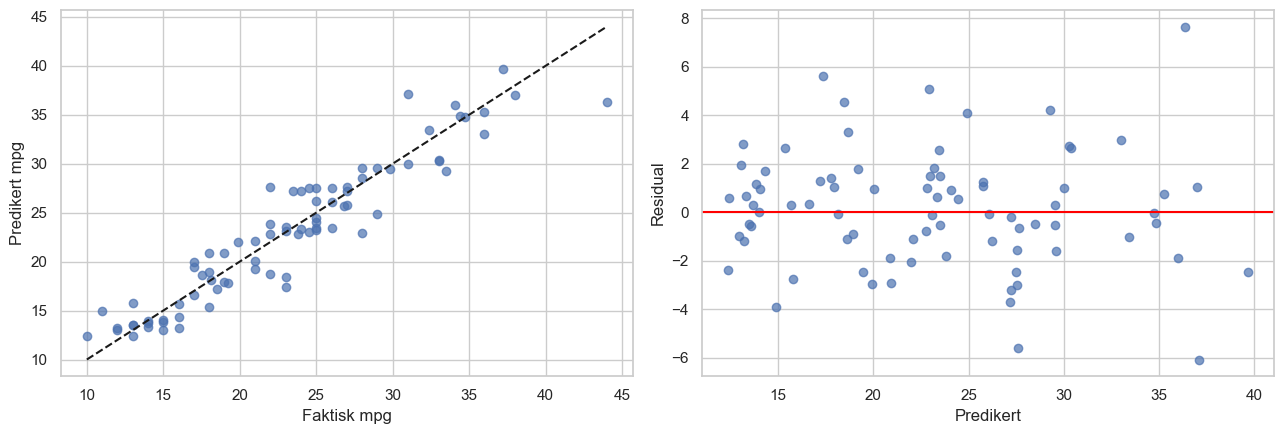

In [7]:
mod = gs.best_estimator_
pred = mod.predict(X_test)
rmse_ = np.sqrt(mean_squared_error(y_test, pred))
print(f"Test:  RMSE = {rmse_:.2f} mpg,  MAE = {mean_absolute_error(y_test, pred):.2f} mpg,  R2 = {r2_score(y_test, pred):.3f}")
print(f"Gjennomsnittlig absolutt feil i forhold til gjennomsnittlig mpg: {mean_absolute_error(y_test, pred) / y_test.mean():.1%}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].scatter(y_test, pred, alpha=0.7)
lim = [y_test.min(), y_test.max()] 
ax[0].plot(lim, lim, "k--")
ax[0].set_xlabel("Faktisk mpg")
ax[0].set_ylabel("Predikert mpg")

ax[1].scatter(pred, y_test - pred, alpha=0.7)
ax[1].axhline(0, color="red")
ax[1].set_xlabel("Predikert")
ax[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()